In [1]:
import sys
from types import MethodType

sys.path.append(r"C:\Users\FranzBraun\Documents\GitHub\nRTD\lib")
from pathlib import Path
import argparse

import numpy as np
import torch
import torch.utils
import torch.utils.data
import wandb
import lightning.pytorch as pl
from lightning.pytorch.loggers.wandb import WandbLogger
from lightning.pytorch.callbacks import LearningRateMonitor

torch.set_default_dtype(torch.float64)

from nRTD import RTDModule, RTDDataModule
#from SweepRunner import Sweeper
import matplotlib.pyplot as plt

plt.style.use("ICIWstyle")

# 1 - Plotting

In [2]:
def log_plots(data_module: RTDDataModule, model: RTDModule, index=0, Es_to_plot=[0]):
    pred_y, pred_t = model(data_module.x, data_module.t_in)
    pred_t = pred_t.detach().numpy().squeeze()
    pred_y = pred_y.detach().numpy().squeeze()

    fig = plt.figure()
    index = 0
    plt.plot(
        data_module.t_in[index],
        data_module.x[index].squeeze(),
        ls="--",
    )
    plt.plot(
        data_module.t_in[index + 2],
        data_module.x[index + 2].squeeze(),
        ls="--",
    )
    plt.plot(
        data_module.t_out[index],
        data_module.y[index].squeeze(),
        "o",
        c="C0",
        markersize=0.5,
    )
    plt.plot(
        data_module.t_out[index + 2],
        data_module.y[index + 2].squeeze(),
        "o",
        c="C1",
        markersize=0.5,
    )
    plt.plot(
        data_module.t_in[index + 1],
        data_module.x[index + 1].squeeze(),
        ls="--",
        c="C2",
    )
    plt.plot(
        data_module.t_in[index + 3],
        data_module.x[index + 3].squeeze(),
        ls="--",
        c="C3",
    )
    plt.plot(
        data_module.t_out[index + 1],
        data_module.y[index + 1].squeeze(),
        "o",
        c="C2",
        markersize=0.5,
    )
    plt.plot(
        data_module.t_out[index + 3],
        data_module.y[index + 3].squeeze(),
        "o",
        c="C3",
        markersize=0.5,
    )

    plt.plot(pred_t[index, :], pred_y[index, :], c="C0")
    plt.plot(pred_t[index + 2].squeeze(), pred_y[index + 2].squeeze(), c="C1")
    plt.plot(pred_t[index + 1, :], pred_y[index + 1, :], c="C2")
    plt.plot(pred_t[index + 3].squeeze(), pred_y[index + 3].squeeze(), c="C3")
    plt.xlabel("t / s")
    plt.ylabel("x / 1")
    plt.twinx()
    ax = plt.gca()
    plt.ylabel("$E \;/\; s^{-1}$")
    my_colors = ["darkmagenta", "goldenrod", "firebrick", "darkcyan"]
    for E_index in Es_to_plot:
        ax.plot(
            model.net.conv_layers[E_index].t_kernel.detach().numpy(),
            model.net.E[E_index],
            color=my_colors[E_index],
        )
    wandb.log({f"RTD_Plot_img": wandb.Image(fig)})
    wandb.log({f"RTD_Plot_fig": fig})

<>:67: SyntaxWarning: invalid escape sequence '\;'
<>:67: SyntaxWarning: invalid escape sequence '\;'
C:\Users\FranzBraun\AppData\Local\Temp\ipykernel_30092\3345537236.py:67: SyntaxWarning: invalid escape sequence '\;'
  plt.ylabel("$E \;/\; s^{-1}$")


# 2 - Constants

In [3]:
### Constants
# givens
t_out = (0.0, 120.0)
print(f"t_out: {t_out}")
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
print(f"n_out: {n_out}")
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
print(f"delta_t_out: {delta_t_out}")

t_halfperiod = t_out[1] - t_out[0]
print(f"t_halfperiod: {t_halfperiod}")

t_kernels = [
    (0.0, 20.0), #30 # piping to reactor inlet
    (0.0, 40.0), #50 # piping after reactor outlet
    (0.0, 20.0), #30 # capillary
] #(0.0, 40.0),  # reactor
print(f"t_kernels: {t_kernels}")

n_kernels = list(
    map(
        lambda t_kernel: int(((t_kernel[1] - t_kernel[0]) / delta_t_out) + 1), t_kernels
    )
)
print(f"n_kernels: {n_kernels}")
t_in = (0, t_out[1] - sum([t_kernel[1] for t_kernel in t_kernels]))
print(f"t_in: {t_in}")
n_in = int(((t_in[1] - t_in[0]) / delta_t_out) + 1)
print(f"n_in: {n_in}")

t_out: (0.0, 120.0)
n_out: 481
delta_t_out: 0.25
t_halfperiod: 120.0
t_kernels: [(0.0, 20.0), (0.0, 40.0), (0.0, 20.0)]
n_kernels: [81, 161, 81]
t_in: (0, 40.0)
n_in: 161


# 3 - Switching times

In [4]:
# total system - switching times 
# create array with half-period times

t_offset = 20.25+45*60+12*10*60+20*60+12*10*60+10*60+5*60 -10 # 45min offset until experiment starts
#t_halfperiod = 300 # 5min half-period duration

switching_times = np.full((24,), 5*60) # 24 half-periods
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]

[19210 19510 19810 20110 20410 20710 21010 21310 21610 21910 22210 22510
 22810 23110 23410 23710 24010 24310 24610 24910 25210 25510 25810 26110
 26410]


In [5]:
# capillary - switching times

t_offset_cap = 872.0550000000003
#t_halfperiod = 300 # 5min half-period duration

switching_times_cap = np.full((10,), 5*60) + np.array([0.05,
                                                          0.18,
                                                          0.27,
                                                          0.33,
                                                          0.26,
                                                          0.18,
                                                          0.28,
                                                          0.27,
                                                          0.27,
                                                          0.03])# 24 half-periods
print(switching_times_cap)

switching_times_cap = np.insert(switching_times_cap, 0, t_offset_cap)
switching_times_cap = np.cumsum(switching_times_cap)
print(switching_times_cap)

intervals_cap = [
    (switching_times_cap[i], switching_times_cap[i + 1])
    for i in range(len(switching_times_cap) - 1)
]
print(intervals_cap)

[300.05 300.18 300.27 300.33 300.26 300.18 300.28 300.27 300.27 300.03]
[ 872.055 1172.105 1472.285 1772.555 2072.885 2373.145 2673.325 2973.605
 3273.875 3574.145 3874.175]
[(np.float64(872.0550000000003), np.float64(1172.1050000000002)), (np.float64(1172.1050000000002), np.float64(1472.2850000000003)), (np.float64(1472.2850000000003), np.float64(1772.5550000000003)), (np.float64(1772.5550000000003), np.float64(2072.885)), (np.float64(2072.885), np.float64(2373.1450000000004)), (np.float64(2373.1450000000004), np.float64(2673.3250000000003)), (np.float64(2673.3250000000003), np.float64(2973.6050000000005)), (np.float64(2973.6050000000005), np.float64(3273.8750000000005)), (np.float64(3273.8750000000005), np.float64(3574.1450000000004)), (np.float64(3574.1450000000004), np.float64(3874.175))]


In [6]:
# reactor inlet - switching times
# create array with half-period times

t_offset_upstream = 3600 + 5 * 60 + 30# offset until experiment starts
#t_halfperiod = 300 # 5min half-period duration

switching_times_reac_inlet = np.full((24,), 5*60) #+ np.array([0.05,
                                                        #   0.18,
                                                        #   0.27,
                                                        #   0.33,
                                                        #   0.26,
                                                        #   0.18,
                                                        #   0.28,
                                                        #   0.27,
                                                        #   0.27,
                                                        #   0.03])# 24 half-periods
print(switching_times_reac_inlet)
switching_times_reac_inlet = np.insert(switching_times_reac_inlet, 0, t_offset_upstream)
switching_times_reac_inlet = np.cumsum(switching_times_reac_inlet)
print(switching_times_reac_inlet)

intervals_reac_inlet = [
    (switching_times_reac_inlet[i], switching_times_reac_inlet[i + 1])
    for i in range(len(switching_times_reac_inlet) - 1)
]
print(intervals_reac_inlet)

[300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300
 300 300 300 300 300 300]
[ 3930  4230  4530  4830  5130  5430  5730  6030  6330  6630  6930  7230
  7530  7830  8130  8430  8730  9030  9330  9630  9930 10230 10530 10830
 11130]
[(np.int64(3930), np.int64(4230)), (np.int64(4230), np.int64(4530)), (np.int64(4530), np.int64(4830)), (np.int64(4830), np.int64(5130)), (np.int64(5130), np.int64(5430)), (np.int64(5430), np.int64(5730)), (np.int64(5730), np.int64(6030)), (np.int64(6030), np.int64(6330)), (np.int64(6330), np.int64(6630)), (np.int64(6630), np.int64(6930)), (np.int64(6930), np.int64(7230)), (np.int64(7230), np.int64(7530)), (np.int64(7530), np.int64(7830)), (np.int64(7830), np.int64(8130)), (np.int64(8130), np.int64(8430)), (np.int64(8430), np.int64(8730)), (np.int64(8730), np.int64(9030)), (np.int64(9030), np.int64(9330)), (np.int64(9330), np.int64(9630)), (np.int64(9630), np.int64(9930)), (np.int64(9930), np.int64(10230)), (np.int64(10230), np.int64(1053

# 4 - WnB initialization

In [7]:
wandb.init(project="HSA_MGA_nRTD", entity="ice_ulm")

wandb: Currently logged in as: franz-braun (ice_ulm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# 5 - DataModules

In [8]:
import sys

sys.path.append(r"C:\Users\FranzBraun\Documents\GitHub\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting import RTDDataModule

data_cap = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"C:\Users\FranzBraun\Documents\GitHub\nRTD\Experiments\AZA_001\A - capillary\AZA-E-130625_250ml-min_2bar_250_Capillary.npz"
    ),
    switching_times=switching_times_cap,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=0.01#0.5#1.0
)

def patch_setup(self, stage: str):
    import scipy

    print("Setup")
    # load the raw data from disc
    with np.load(self.data_file) as data:
        n_dot = data["n_dot"]
        times = data["time_delta"]

    # interpolate the data to the measured time scale
    interp = scipy.interpolate.interp1d(
        times,
        n_dot,
        kind="linear",
        fill_value="extrapolate",
    )
    # calculate the time scales for the input and output data
    t_in = np.linspace(
        self.t_range_in[0],
        self.t_range_in[1],
        self.n_in,
    )
    t_out = np.linspace(
        self.t_range_out[0],
        self.t_range_out[1],
        self.n_out,
    )
    delta_t = (self.t_range_out[1] - self.t_range_out[0]) / (self.n_out - 1)

    # for each interval in ther switching periods, interpolate the data on that interval
    for i, interval in enumerate(self.intervals):
        # check if the period is even or odd
        even_period = i % 2 == 0
        # begin of interpolation
        interp_begin = interval[0] + self.t_range_out[0]
        # end of interpolation
        interp_end = interp_begin + self.t_range_out[-1]
        # auxilliray time scale for the interpolation
        # 15 seconds of the end of each signal will be repeated to pad out the signal to 2 min
        interp_aux = interp_begin + 30
        # available time scale for interpolation
        #  hard coded 15 seconds
        interp_avail = interp_begin + 45

        t_interp = np.linspace(
            interp_begin,
            interp_end,
            self.n_out,
        )
        n_avail = int((interp_avail - interp_begin) / delta_t + 1)
        t_avail = np.linspace(
            interp_begin,
            interp_avail,
            n_avail,
        )
        n_aux = int((interp_avail - interp_aux) / delta_t)
        t_aux = np.linspace(
            interp_aux,
            interp_avail,
            n_aux,
        )

        # we only care about Ar and He as tracers
        n_dot_interp_avail = interp(t_avail)[
            [0, 1]
        ]  # shape is (2, n_out) that is two valid samples
        n_dot_interp_aux = interp(t_aux)[[0, 1]]
        n_dot_interp_aux = np.tile(n_dot_interp_aux, (1, 5))
        n_dot_interp = np.concatenate([n_dot_interp_avail, n_dot_interp_aux], axis=1)

        # get the respective 0 and 1 values for the switch
        if even_period:
            try:
                even_steady_state_values = np.append(
                    even_steady_state_values, n_dot_interp[None, :, [0, -1]], axis=0
                )
            except NameError:
                even_steady_state_values = n_dot_interp[None, :, [0, -1]]
        else:
            try:
                odd_steady_state_values = np.append(
                    odd_steady_state_values, n_dot_interp[None, :, [0, -1]], axis=0
                )
            except NameError:
                odd_steady_state_values = n_dot_interp[None, :, [0, -1]]

        # stack the interpolated data
        try:
            y = np.vstack((y, n_dot_interp))
        except NameError:
            y = n_dot_interp

    #  take the mean over all samples to get somewhat reliable steady state values
    even_steady_state_values = even_steady_state_values.mean(
        axis=0
    )  # shape (2,2) first index is species, second index is the steady state
    odd_steady_state_values = odd_steady_state_values.mean(axis=0)

    # claculate the step functions for each interval
    for i, interval in enumerate(self.intervals):
        # check if the period is even or odd
        even_period = i % 2 == 0

        if even_period:
            steady_state_values = even_steady_state_values
        else:
            steady_state_values = odd_steady_state_values

        n_dot_in = np.zeros((2, self.n_in))
        n_dot_in[0, :] = np.where(
            t_in < self.switch_delay,
            steady_state_values[0, 0],
            steady_state_values[0, 1],
        )
        n_dot_in[1, :] = np.where(
            t_in < self.switch_delay,
            steady_state_values[1, 0],
            steady_state_values[1, 1],
        )

        # stack the step functions
        try:
            x = np.vstack((x, n_dot_in))
        except NameError:
            x = n_dot_in
    self.y = torch.Tensor(y)[:, None, :]
    self.x = torch.tensor(x)[:, None, :]
    t_in = torch.tensor(t_in)
    t_out = torch.tensor(t_out)
    self.t_in = torch.tile(t_in, (2 * len(self.intervals), 1))
    self.t_out = torch.tile(t_out, (2 * len(self.intervals), 1))
    self.data_set = torch.utils.data.TensorDataset(self.x, self.t_in, self.y)
    self.train_set, self.test_set = torch.utils.data.random_split(
        self.data_set,
        [
            int(0.8 * len(self.data_set)),
            len(self.data_set) - int(0.8 * len(self.data_set)),
        ],
    )


data_cap.setup = MethodType(patch_setup, data_cap)

In [9]:
# %matplotlib inline
# plt.plot(data_cap.t_in[0,:], data_cap.x[0,0,:])
# plt.show()
# plt.close()

In [10]:
# # plot t_in über x
# %matplotlib inline
# plt.figure()

# for i in np.arange(0,20):
#     if i %2==0:
#         plt.plot(data_cap.t_out[i, :], data_cap.y[i, 0, ...], label="Ar")
# plt.show()
# plt.close()

In [11]:
import sys

sys.path.append(r"C:\Users\FranzBraun\Documents\GitHub\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting import RTDDataModule

data_reac_inlet = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"C:\Users\FranzBraun\Documents\GitHub\nRTD\Experiments\AZA_001\B - upstream\AZA-E-130625_250ml-min_2bar_250_upstream.npz"
    ),
    switching_times=switching_times_reac_inlet,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=0.0001,
)

In [12]:
# data_reac_outlet = RTDDataModule(
#     batch_size=32,
#     data_file=Path(
#         r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_003\data\MGA-E-11032025_30ml-min_1atm_ReactorOutlet_MS.npz"
#     ),
#     switching_times=switching_times_reac_outlet,
#     t_range_in=t_in,
#     n_in=n_in,
#     t_range_out=t_out,
#     n_out=n_out,
#     switch_delay=1.0,
# )

In [13]:
import sys

sys.path.append(r"C:\Users\FranzBraun\Documents\GitHub\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting import RTDDataModule

data_total_system = RTDDataModule(
    batch_size = 32, # 2 temperatures, 2 half-periods, 4 different capillary positions
    data_file = Path(
        r"C:\Users\FranzBraun\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_ges_system\RTD_ges_sys_280C_320C\FBA_250ml-min_2bar_250_TotalSystem.npz"
    ),
    switching_times = switching_times,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=0.1,
)

In [14]:
data_cap.setup("fit")
data_cap.x[0]

Setup


tensor([[3.3264e-06, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e

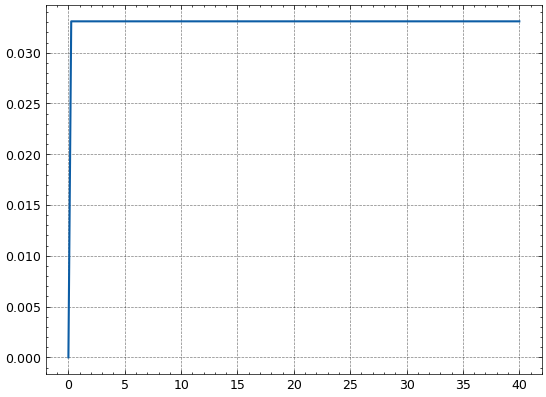

In [15]:
%matplotlib inline
plt.plot(data_cap.t_in[0,:], data_cap.x[0,0,:])
plt.show()
plt.close()

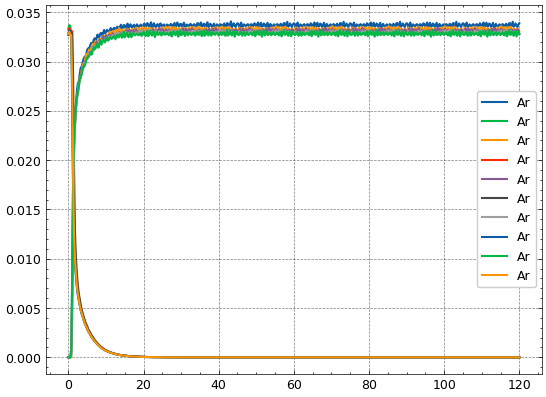

In [16]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if i %2==0:
        plt.plot(data_cap.t_out[i, :], data_cap.y[i, 0, ...], label="Ar")
plt.legend()
plt.show()
plt.close()

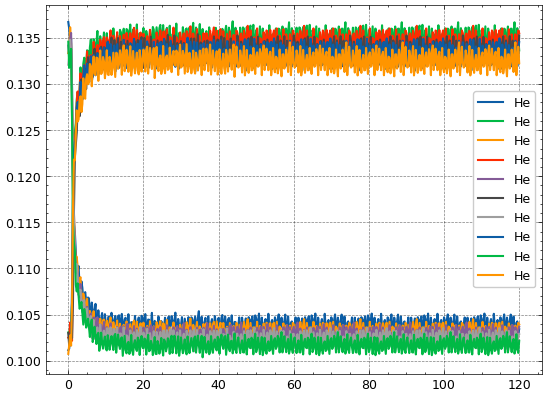

In [17]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if not i %2==0:
        plt.plot(data_cap.t_out[i, :], data_cap.y[i, 0, ...], label="He")
plt.legend()
plt.show()
plt.close()

In [18]:
data_reac_inlet.setup("fit")
data_reac_inlet.x[0]

tensor([[8.7911e-05, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e

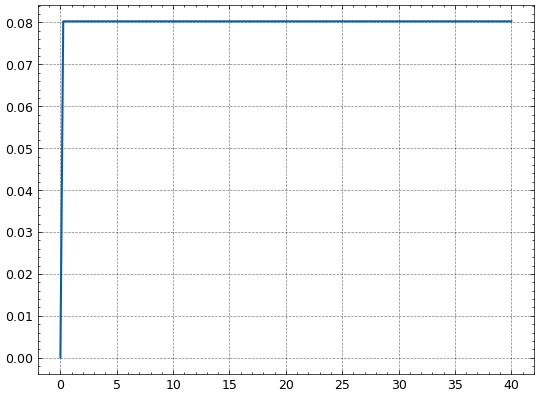

In [19]:
%matplotlib inline
plt.plot(data_reac_inlet.t_in[0,:], data_reac_inlet.x[0,0,:])
plt.show()
plt.close()

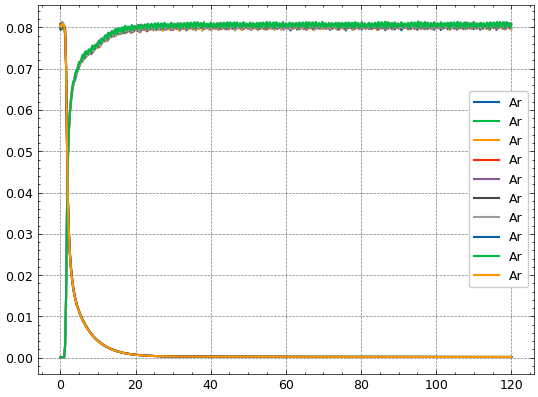

In [20]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if i %2==0:
        plt.plot(data_reac_inlet.t_out[i, :], data_reac_inlet.y[i, 0, ...], label="Ar")
plt.legend()
plt.show()
plt.close()

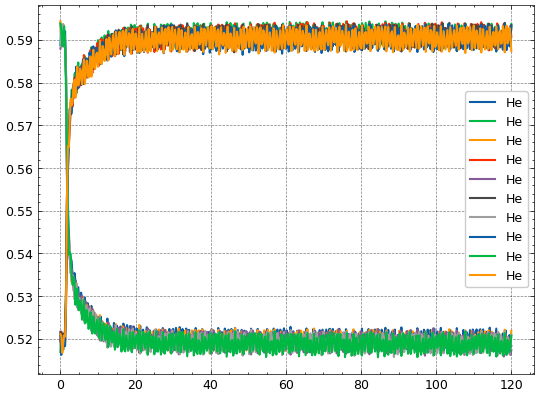

In [21]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if not i %2==0:
        plt.plot(data_reac_inlet.t_out[i, :], data_reac_inlet.y[i, 0, ...], label="He")
plt.legend()
plt.show()
plt.close()

In [22]:
data_total_system.setup("fit")
data_total_system.x[0]

tensor([[3.2193e-05, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02, 4.5177e-02,
         4.5177e-02, 4.5177e

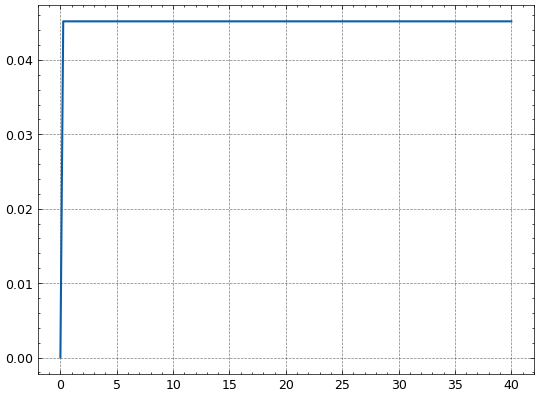

In [23]:
%matplotlib inline
plt.plot(data_total_system.t_in[0,:], data_total_system.x[0,0,:])
plt.show()
plt.close()

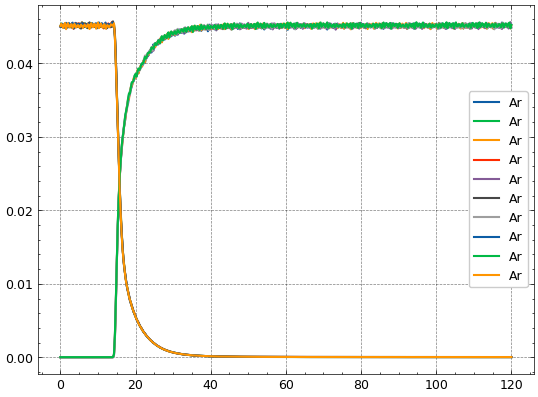

In [24]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if i %2==0:
        plt.plot(data_total_system.t_out[i, :], data_total_system.y[i, 0, ...], label="Ar")
plt.legend()
plt.show()
plt.close()

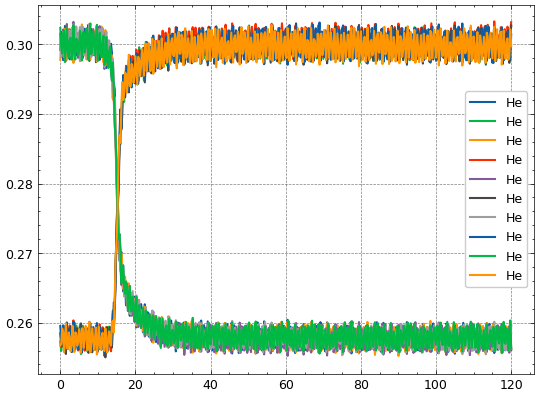

In [25]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if not i %2==0:
        plt.plot(data_total_system.t_out[i, :], data_total_system.y[i, 0, ...], label="He")
plt.legend()
plt.show()
plt.close()

# 6 - Model setup

In [26]:
model = RTDModule(
    kernel_sizes = n_kernels,
    kernel_times = t_kernels,
    learning_rate = 4e-4,
    use_scheduler = False,
    scheduler_kwargs = {"factor": 0.6, "patience": 2000},
)

# 7 - Trainer initialization

In [27]:
# #%pip install litmodels
#from litmodels import LitModelCheckpoint
# #import litmodels

my_logger = WandbLogger(log_model=True)
lr_callback = LearningRateMonitor()

max_epochs = 20_000

trainer = pl.Trainer(
    accelerator="cpu",
    max_epochs=max_epochs,
    enable_progress_bar=True,
    logger=my_logger,
    callbacks=[lr_callback],
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


# 8 - Training

In [28]:
for conv_layer in model.net.conv_layers:
    conv_layer.set_to_direct_response()
    conv_layer.freeze()
    print(conv_layer)

RTDConv(
  (conv): Conv1d(1, 1, kernel_size=(81,), stride=(1,), padding=(80,), bias=False, padding_mode=replicate)
)
RTDConv(
  (conv): Conv1d(1, 1, kernel_size=(161,), stride=(1,), padding=(160,), bias=False, padding_mode=replicate)
)
RTDConv(
  (conv): Conv1d(1, 1, kernel_size=(81,), stride=(1,), padding=(80,), bias=False, padding_mode=replicate)
)


In [29]:
model.net.conv_layers[2].unfreeze()
trainer.fit(model, data_cap)

log_plots(
    data_module=data_cap,
    model=model,
    index=0,
    Es_to_plot=[2],
)
# child 0, overshoot für t=0
model.net.conv_layers[2].freeze() 

c:\Users\FranzBraun\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\FranzBraun\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\loggers\wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type   | Params | Mode 
----------------------------------------
0 | net  | RTDNet | 323    | train
----------------------------------------
81        Trainable params
242       Non-trainable params
323       Total params
0.001     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
c:\Users\FranzBraun\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.p

Setup
Epoch 19999: 100%|██████████| 1/1 [00:00<00:00, 72.88it/s, v_num=4u5b, train/loss=7.62e-7] 

`Trainer.fit` stopped: `max_epochs=20000` reached.


Epoch 19999: 100%|██████████| 1/1 [00:00<00:00, 46.64it/s, v_num=4u5b, train/loss=7.62e-7]


In [30]:
model.net.conv_layers[0].unfreeze()
model.configure_optimizers()
trainer = pl.Trainer(
    accelerator="cpu",
    max_epochs=max_epochs,
    enable_progress_bar=True,
    logger=my_logger,
    callbacks=[lr_callback],
)
trainer.fit(model, data_reac_inlet)

log_plots(
    data_module=data_reac_inlet,
    model=model,
    index=0,
    Es_to_plot=[0, 2],
)
# child 1, even stronger overshoot for t=0
model.net.conv_layers[0].freeze()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\FranzBraun\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: PossibleUserWarning:

You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

c:\Users\FranzBraun\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:658: UserWarning:

Checkpoint directory .\lightning_logs\nxce4u5b\checkpoints exists and is not empty.


  | Name | Type   | Params | Mode 
----------------------------------------
0 | net  | RTDNet | 323    | train
----------------------------------------
81        Trainable params
242       Non-trainable params
323 

Epoch 19999: 100%|██████████| 2/2 [00:00<00:00, 64.95it/s, v_num=4u5b, train/loss=4.79e-6] 

`Trainer.fit` stopped: `max_epochs=20000` reached.


Epoch 19999: 100%|██████████| 2/2 [00:00<00:00, 50.94it/s, v_num=4u5b, train/loss=4.79e-6]


In [31]:
# model.net.conv_layers[1].unfreeze()
# model.configure_optimizers()
# trainer = pl.Trainer(
#     accelerator="cpu",
#     max_epochs=max_epochs,
#     enable_progress_bar=True,
#     logger=my_logger,
#     callbacks=[lr_callback],
# )
# trainer.fit(model, data_reac_outlet)

# log_plots(
#     data_module=data_reac_outlet,
#     model=model,
#     index=0,
#     Es_to_plot=[0, 1, 3],
# )

# model.net.conv_layers[1].freeze()

In [32]:
model.net.conv_layers[1].unfreeze()
model.configure_optimizers()
trainer = pl.Trainer(
    accelerator="cpu",
    max_epochs=max_epochs,
    enable_progress_bar=True,
    logger=my_logger,
    callbacks=[lr_callback],
)
trainer.fit(model, data_total_system)

log_plots(
    data_module=data_total_system,
    model=model,
    index=0,
    Es_to_plot=[0, 1, 2],
)

plt.show()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type   | Params | Mode 
----------------------------------------
0 | net  | RTDNet | 323    | train
----------------------------------------
161       Trainable params
162       Non-trainable params
323       Total params
0.001     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 19999: 100%|██████████| 2/2 [00:00<00:00, 62.18it/s, v_num=4u5b, train/loss=2.15e-6] 

`Trainer.fit` stopped: `max_epochs=20000` reached.


Epoch 19999: 100%|██████████| 2/2 [00:00<00:00, 49.17it/s, v_num=4u5b, train/loss=2.15e-6]


In [33]:
%pip install plotly

log_plots(
    data_module=data_total_system,
    model=model,
    index=0,
    Es_to_plot=[0, 1, 2],
)

plt.show()

Note: you may need to restart the kernel to use updated packages.


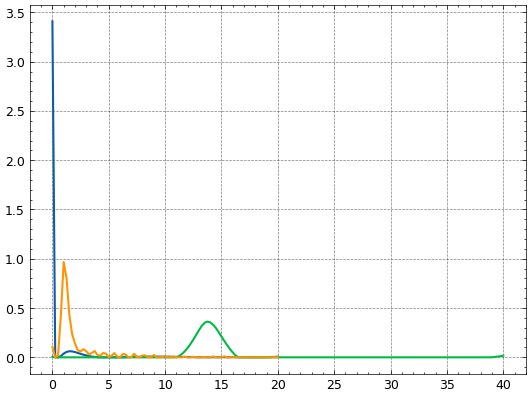

In [34]:
Es = []
ts = []
delta_ts = []

for i in np.arange(0,3):#
    Es.append(model.net.E[i].detach().numpy())
    ts.append(model.net.conv_layers[i].t_kernel.detach().numpy())
    delta_ts.append(delta_ts.append(model.net.delta_t[i].item()))
    plt.plot(ts[i], Es[i])

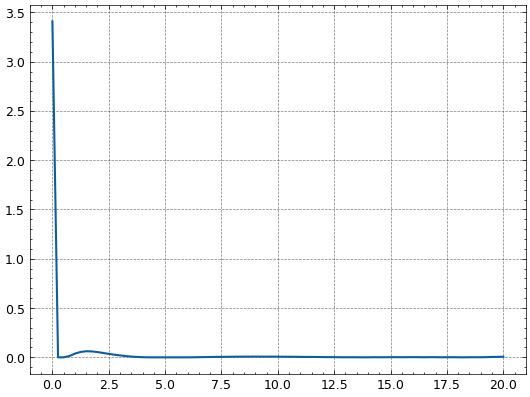

In [35]:
plt.plot(ts[0], Es[0])

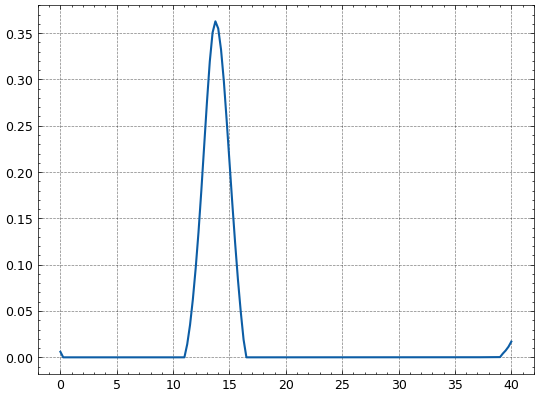

In [36]:
plt.plot(ts[1], Es[1])

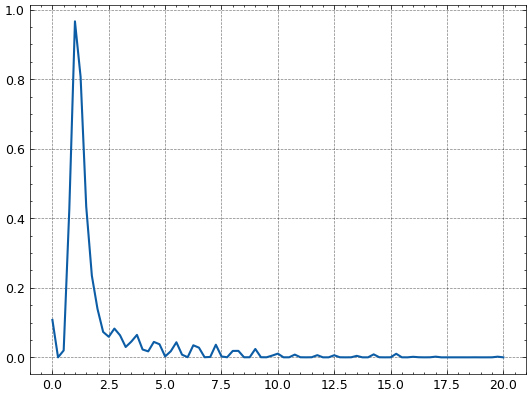

In [37]:
plt.plot(ts[2], Es[2])

In [41]:
from datetime import datetime
d=datetime.now().strftime("%Y-%m-%d_%H%M%S")

data ={'ts':ts,
        'Es':Es,
        'delta_ts':delta_ts,

        't_in cap':data_cap.t_in.detach().numpy(),
        'x_in cap':data_cap.x.detach().numpy(),
        't_out cap':data_cap.t_out.detach().numpy(),
        'x_out cap':data_cap.y.detach().numpy(),

        't_in upstream':data_reac_inlet.t_in.detach().numpy(),
        'x_in upstream':data_reac_inlet.x.detach().numpy(),
        't_out upstream':data_reac_inlet.t_out.detach().numpy(),
        'x_out upstream':data_reac_inlet.y.detach().numpy(),

        't_in total':data_total_system.t_in.detach().numpy(),
        'x_in total':data_total_system.x.detach().numpy(),
        't_out total':data_total_system.t_out.detach().numpy(),
        'x_out total':data_total_system.y.detach().numpy(),}

np.save(f"C:\\Users\\FranzBraun\\Nextcloud\\PTK_Projekte\\Auswertung_FBA\\RTD_FBA\\RTD_ges_system\\fertige_RTDs\\Run_280C_250nmlmin_{d}.npy", data)

In [42]:
from scipy.integrate import simpson

taus = []
for i in np.arange(0,3):
    print('eee',ts, 'ddd',delta_ts)
    I = simpson(Es[i], x=ts[i]) #+ 1 / 2 * Es[i,0] * delta_ts[i] + 1 / 2 * Es[i,-1] * delta_ts
    print(I)
    # dummy_I = I - Es[i,0] * delta_ts
    # print(f"{I=: .3f}")
    # tau = simpson(ts[i] * Es[i] / dummy_I, x=ts[i])
    # taus.append(tau)
    # sigma = simpson((ts[i] - tau) ** 2 * Es[i] / dummy_I, x=ts[i])
    # print(f"{tau=:.2f}")
    # print(f"{sigma=:.2f}")

eee [array([ 0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,
        2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,
        4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,
        6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,
        9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 , 10.75, 11.  ,
       11.25, 11.5 , 11.75, 12.  , 12.25, 12.5 , 12.75, 13.  , 13.25,
       13.5 , 13.75, 14.  , 14.25, 14.5 , 14.75, 15.  , 15.25, 15.5 ,
       15.75, 16.  , 16.25, 16.5 , 16.75, 17.  , 17.25, 17.5 , 17.75,
       18.  , 18.25, 18.5 , 18.75, 19.  , 19.25, 19.5 , 19.75, 20.  ]), array([ 0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,
        2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,
        4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,
        6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,
        9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 , 10.75, 11.  ,
       11.25,